arxiko T: 126.5
Neo T: 116.37067
Delta 10.1293335
Neo T: 111.45829
Delta 4.9123764
Neo T: 109.19204
Delta 2.2662506
Neo T: 108.34102
Delta 0.8510208


(np.float64(-0.5), np.float64(383.5), np.float64(302.5), np.float64(-0.5))

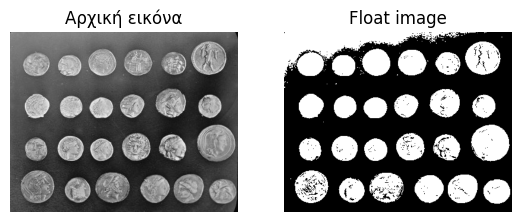

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage import img_as_ubyte
import cv2 as cv

# Load example grayscale image
img = img_as_ubyte(data.coins())

#img = cv.equalizeHist(img1)

# Μετατροπή σε float για υπολογισμούς
f = img.astype(np.float32)

# Αρχικό κατώφλι ως μέσο όρο min και max
T = 0.5 * (f.min() + f.max())
#Τ = f.mean()
print("arxiko T:",T)

# Παράμετρος ανοχής για τερματισμό (π.χ. διαφορά < 5 μονάδες φωτεινότητας)
tol = 2
delta = np.inf

# Επαναληπτικός υπολογισμός μέχρι σύγκλιση
while delta > tol:
    # Διχοτόμηση σε δύο ομάδες
    bg = f < T     # υπόβαθρο
    fg = f >= T    # αντικείμενα

    # Μέσοι όροι φωτεινότητας κάθε ομάδας
    m1 = f[bg].mean() if np.any(bg) else 0.0
    m2 = f[fg].mean() if np.any(fg) else 0.0

    # Νέο κατώφλι
    Tnext = 0.5 * (m1 + m2)

    # Έλεγχος τερματισμού
    print("Neo T:",Tnext)
    delta = abs(T - Tnext)
    print("Delta",delta)
    T = Tnext


# Δημιουργία δυαδικής εικόνας με το τελικό κατώφλι
bw = (f >= T).astype(np.uint8) * 255

# Εμφάνιση αποτελεσμάτων με matplotlib
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title('Αρχική εικόνα')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(bw, cmap='gray')
plt.title('Float image')
plt.axis('off')
